In [313]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [314]:
plt.style.use("ggplot")

In [315]:
df = pd.read_csv("email.csv")
df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [316]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5573 entries, 0 to 5572
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5573 non-null   object
 1   Message   5573 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [317]:
df.isna().sum()


Category    0
Message     0
dtype: int64

In [318]:
df.describe()

,Category,Message
count,5573,5573
unique,3,5158
top,ham,"Sorry, I'll call later"
freq,4825,30


In [319]:
df.tail(3)

,Category,Message
5570,ham,The guy did some bitching but I acted like i'd...
5571,ham,Rofl. Its true to its name
5572,"{""mode"":""full""",isActive:false}


In [320]:
df['Category'].value_counts()

Category
ham               4825
spam               747
{"mode":"full"       1
Name: count, dtype: int64

In [321]:
df = df.iloc[:-1]


In [322]:
df.tail()

,Category,Message
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...
5571,ham,Rofl. Its true to its name


In [323]:
df.head(3)

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...


In [324]:
df.shape

(5572, 2)

In [325]:
df.dtypes

Category    object
Message     object
dtype: object

In [326]:
df.isna().sum().sum()

np.int64(0)

In [327]:
df.duplicated().sum() /df.shape[0]

np.float64(0.07447954055994258)

In [328]:
df.drop_duplicates(inplace = True)

In [329]:
df

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [330]:
df['Category'].value_counts()

Category
ham     4516
spam     641
Name: count, dtype: int64

In [331]:
df['Category'].value_counts(normalize= True ) * 100

Category
ham     87.570293
spam    12.429707
Name: proportion, dtype: float64

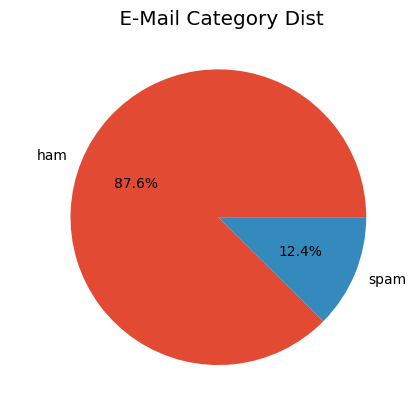

In [332]:
df['Category'].value_counts().plot(
    kind="pie",
    autopct = "%1.1f%%"
)
plt.ylabel(" ")

plt.title(" E-Mail Category Dist")

plt.show()

In [333]:
df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [334]:
df["Message_Length"] = df["Message"].apply(len)

In [335]:
df.head()

,Category,Message,Message_Length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


In [336]:
df["Message"][2]

"Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's"

In [337]:
df["Message_Length"].describe()

count    5157.000000
mean       79.103936
std        58.382922
min         2.000000
25%        36.000000
50%        61.000000
75%       118.000000
max       910.000000
Name: Message_Length, dtype: float64

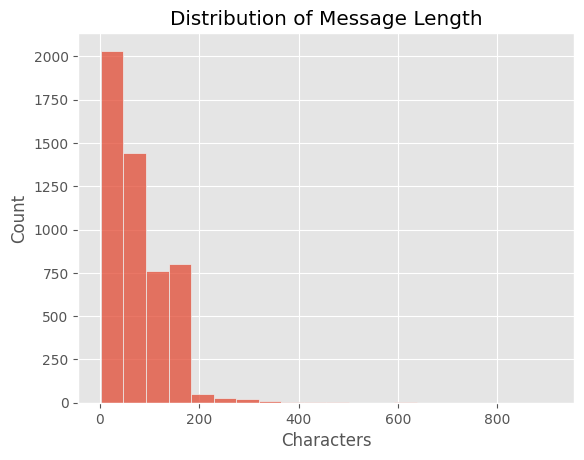

In [338]:
sns.histplot(df["Message_Length"], bins =20)

plt.title("Distribution of Message Length")

plt.xlabel("Characters")

plt.show()

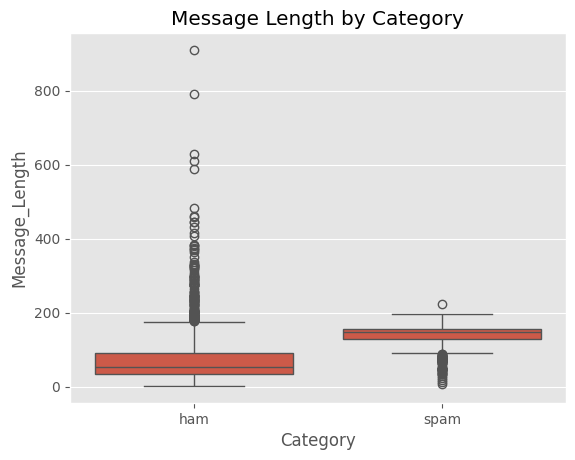

In [339]:
sns.boxplot(
    data = df,
    x = "Category",
    y = "Message_Length"
)

plt.title("Message Length by Category")
plt.show()

In [340]:
df.groupby("Category")["Message_Length"].mean()

Category
ham      70.869353
spam    137.118565
Name: Message_Length, dtype: float64

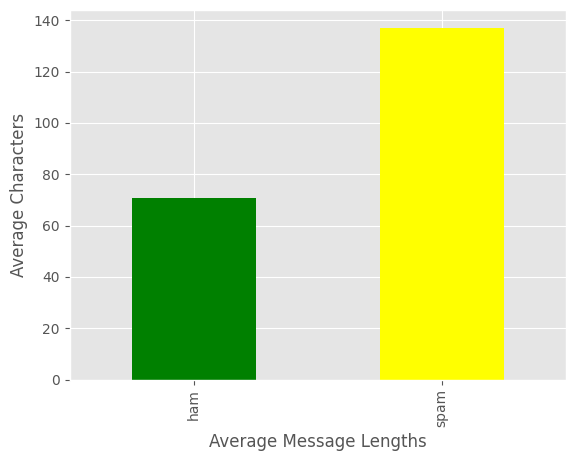

In [341]:
df.groupby("Category")["Message_Length"].mean().plot(
    kind = "bar",
    color =["green","yellow"]

)

plt.ylabel("Average Characters")

plt.xlabel("Average Message Lengths")

plt.show()

In [342]:
df.head()

,Category,Message,Message_Length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


In [343]:
df["Word_Count"] = df["Message"] .apply(lambda x: len(x.split()))

In [344]:
df.head(2)

,Category,Message,Message_Length,Word_Count
0,ham,"Go until jurong point, crazy.. Available only ...",111,20
1,ham,Ok lar... Joking wif u oni...,29,6


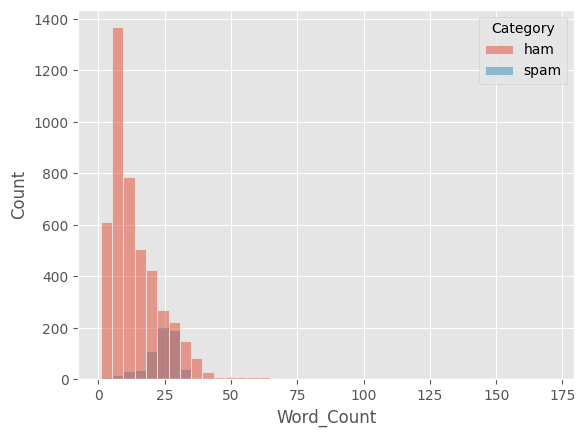

In [345]:
sns.histplot(
    data = df,
    x = "Word_Count",
    hue = "Category",
    bins = 40
)

plt.show()

In [346]:
df.groupby("Category")["Word_Count"].mean()

Category
ham     14.239814
spam    23.659906
Name: Word_Count, dtype: float64

In [347]:
df.nsmallest(10,"Message_Length")

,Category,Message,Message_Length,Word_Count
1925,ham,Ok,2,1
3376,ham,:),2,1
261,ham,Yup,3,1
1612,ham,645,3,1
2182,ham,Ok.,3,1
287,ham,Ok..,4,1
2602,ham,Okie,4,1
5173,ham,U 2.,4,2
1273,ham,Ok...,5,1
4293,ham,G.W.R,5,1


In [348]:
df.nlargest(5,"Message_Length")

,Category,Message,Message_Length,Word_Count
1085,ham,For me the love should start with attraction.i...,910,171
1863,ham,The last thing i ever wanted to do was hurt yo...,790,162
2434,ham,Indians r poor but India is not a poor country...,629,109
1579,ham,How to Make a girl Happy? It's not at all diff...,611,103
2158,ham,Sad story of a Man - Last week was my b'day. M...,588,125


In [349]:
df[df["Category"] == 'spam'].sample(5)

,Category,Message,Message_Length,Word_Count
1414,spam,Dear U've been invited to XCHAT. This is our f...,143,22
576,spam,"You have won ?1,000 cash or a ?2,000 prize! To...",69,12
1308,spam,"Get 3 Lions England tone, reply lionm 4 mono o...",155,28
8,spam,WINNER!! As a valued network customer you have...,157,26
3999,spam,We tried to call you re your reply to our sms ...,143,28


In [350]:
df[df["Category"] == "ham"].sample(4,random_state=1)

,Category,Message,Message_Length,Word_Count
1258,ham,Am also doing in cbe only. But have to pay.,43,10
5180,ham,Babe! I fucking love you too !! You know? Fuck...,157,34
1296,ham,TELL HER I SAID EAT SHIT.,25,6
4886,ham,Poor girl can't go one day lmao,31,7


In [351]:
df['Category'] = df['Category'].map({
    "ham" : 0,
    "spam" : 1
})

In [352]:
df.head(3)

,Category,Message,Message_Length,Word_Count
0,0,"Go until jurong point, crazy.. Available only ...",111,20
1,0,Ok lar... Joking wif u oni...,29,6
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,28


In [353]:
import warnings
warnings.filterwarnings("ignore")

In [354]:
from sklearn.model_selection import train_test_split


In [355]:
X = df ["Message"]
y = df ["Category"]

In [356]:
X_train,X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    stratify = y 
)

In [357]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words ="english",
    max_features = 5000,
    ngram_range = (1,2)
)

In [358]:
X_train_tfidf = tfidf.fit_transform(X_train)

In [359]:
X_test_tfidf = tfidf.transform(X_test)

In [360]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import RandomizedSearchCV

In [361]:
models = {
    "Naive Bayes" :(
        MultinomialNB(),
        {
            "alpha" : [0.1, 0.5, 1, 2, 5]
        }
    ),

    "LogisticRegression" :(
        LogisticRegression(
            class_weight= "balanced",
            max_iter= 1000
        ),
        {
            "C" : [0.01,0.1, 1, 10, 100]
        }
    ),
    "LinearSVM" : (
        LinearSVC(
            class_weight= "balanced"
        ),
            {
        "C" : [0.01,0.1 ,1,10]
        }

    ),

    "Random Forest" : (
        RandomForestClassifier(
            class_weight = "balanced"

        ),
        {
            "n_estimators" : [100, 200, 300],
            "max_depth" :[10,20, None],
            "min_samples_split" :[2,5, 10]

        }
    ),

    "DecisionTree" : (
        DecisionTreeClassifier(
            class_weight= "balanced"
        ),
        {
            "max_depth": [5, 10, 20, None],
            "min_samples_split" : [2,5, 10]
        }
    ),

    "Gradient Boosting" :(
        GradientBoostingClassifier(),
        {
            "n_estimators": [100, 200],
            "learning_rate": [0.01, 0.05, 0.1],
            "max_depth": [3,5]
        }
    ),
    "KNN": (
        KNeighborsClassifier(),
        {
            "n_neighbors": [3,5, 7, 9]
        }
    ) 
}

In [362]:
results = []

best_models = {}

for name, (model, params) in models.items():

    search = RandomizedSearchCV(
        estimator= model,
        param_distributions= params,
        n_iter= 10,
        cv= 5,
        scoring= "f1",
        n_jobs= -1
    )

    search.fit(X_train_tfidf, y_train)

    best_model = search.best_estimator_

    best_models[name] = best_model

    predictions = best_model.predict(X_test_tfidf)


    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)

    try:
        auc = roc_auc_score(y_test, best_model.decision_function(X_test_tfidf))
    except:
        try:
            auc = roc_auc_score(
                y_test,
                best_model.predict_proba(X_test_tfidf) [:,1]
            )
        except:
            auc =np.nan

    results.append({
        "Model": name,
        "Accuracy" :accuracy,
        "Precision" : precision,
        "Recall" :recall,
        "F1 Score": f1,
        "ROC AUC": auc,
        "Best Params": search.best_params_

    })

In [363]:
results

[{'Model': 'Naive Bayes',
  'Accuracy': 0.9835271317829457,
  'Precision': 0.9663865546218487,
  'Recall': 0.8984375,
  'F1 Score': 0.9311740890688259,
  'ROC AUC': 0.9939937085176991,
  'Best Params': {'alpha': 0.1}},
 {'Model': 'LogisticRegression',
  'Accuracy': 0.9864341085271318,
  'Precision': 0.9453125,
  'Recall': 0.9453125,
  'F1 Score': 0.9453125,
  'ROC AUC': 0.9972604397123894,
  'Best Params': {'C': 100}},
 {'Model': 'LinearSVM',
  'Accuracy': 0.9815891472868217,
  'Precision': 0.916030534351145,
  'Recall': 0.9375,
  'F1 Score': 0.9266409266409267,
  'ROC AUC': 0.9965690680309736,
  'Best Params': {'C': 0.1}},
 {'Model': 'Random Forest',
  'Accuracy': 0.9874031007751938,
  'Precision': 0.9752066115702479,
  'Recall': 0.921875,
  'F1 Score': 0.9477911646586346,
  'ROC AUC': 0.9952468196902655,
  'Best Params': {'n_estimators': 300,
   'min_samples_split': 10,
   'max_depth': None}},
 {'Model': 'DecisionTree',
  'Accuracy': 0.9476744186046512,
  'Precision': 0.7605633802816

In [364]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by = "F1 Score",
    ascending= False
)

In [365]:
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Best Params
3,Random Forest,0.987403,0.975207,0.921875,0.947791,0.995247,"{'n_estimators': 300, 'min_samples_split': 10,..."
1,LogisticRegression,0.986434,0.945312,0.945312,0.945312,0.997260,{'C': 100}
0,Naive Bayes,0.983527,0.966387,0.898438,0.931174,0.993994,{'alpha': 0.1}
2,LinearSVM,0.981589,0.916031,0.937500,0.926641,0.996569,{'C': 0.1}
5,Gradient Boosting,0.964147,0.950495,0.750000,0.838428,0.980464,"{'n_estimators': 100, 'max_depth': 5, 'learnin..."
4,DecisionTree,0.947674,0.760563,0.843750,0.800000,0.908169,"{'min_samples_split': 5, 'max_depth': None}"
6,KNN,0.923450,1.000000,0.382812,0.553672,0.789326,{'n_neighbors': 3}


In [366]:
results_df.style.background_gradient(
    cmap= "Greens",
    subset=[ "Accuracy","Precision","Recall","F1 Score","ROC AUC"]
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Best Params
3,Random Forest,0.987403,0.975207,0.921875,0.947791,0.995247,"{'n_estimators': 300, 'min_samples_split': 10, 'max_depth': None}"
1,LogisticRegression,0.986434,0.945312,0.945312,0.945312,0.997260,{'C': 100}
0,Naive Bayes,0.983527,0.966387,0.898438,0.931174,0.993994,{'alpha': 0.1}
2,LinearSVM,0.981589,0.916031,0.937500,0.926641,0.996569,{'C': 0.1}
5,Gradient Boosting,0.964147,0.950495,0.750000,0.838428,0.980464,"{'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.1}"
4,DecisionTree,0.947674,0.760563,0.843750,0.800000,0.908169,"{'min_samples_split': 5, 'max_depth': None}"
6,KNN,0.923450,1.000000,0.382812,0.553672,0.789326,{'n_neighbors': 3}


In [367]:
results_df.reset_index(inplace= True)
results_df

,index,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Best Params
0,3,Random Forest,0.987403,0.975207,0.921875,0.947791,0.995247,"{'n_estimators': 300, 'min_samples_split': 10,..."
1,1,LogisticRegression,0.986434,0.945312,0.945312,0.945312,0.997260,{'C': 100}
2,0,Naive Bayes,0.983527,0.966387,0.898438,0.931174,0.993994,{'alpha': 0.1}
3,2,LinearSVM,0.981589,0.916031,0.937500,0.926641,0.996569,{'C': 0.1}
4,5,Gradient Boosting,0.964147,0.950495,0.750000,0.838428,0.980464,"{'n_estimators': 100, 'max_depth': 5, 'learnin..."
5,4,DecisionTree,0.947674,0.760563,0.843750,0.800000,0.908169,"{'min_samples_split': 5, 'max_depth': None}"
6,6,KNN,0.923450,1.000000,0.382812,0.553672,0.789326,{'n_neighbors': 3}


In [368]:
results_df.drop(columns= "index", inplace=True)

In [369]:
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Best Params
0,Random Forest,0.987403,0.975207,0.921875,0.947791,0.995247,"{'n_estimators': 300, 'min_samples_split': 10,..."
1,LogisticRegression,0.986434,0.945312,0.945312,0.945312,0.997260,{'C': 100}
2,Naive Bayes,0.983527,0.966387,0.898438,0.931174,0.993994,{'alpha': 0.1}
3,LinearSVM,0.981589,0.916031,0.937500,0.926641,0.996569,{'C': 0.1}
4,Gradient Boosting,0.964147,0.950495,0.750000,0.838428,0.980464,"{'n_estimators': 100, 'max_depth': 5, 'learnin..."
5,DecisionTree,0.947674,0.760563,0.843750,0.800000,0.908169,"{'min_samples_split': 5, 'max_depth': None}"
6,KNN,0.923450,1.000000,0.382812,0.553672,0.789326,{'n_neighbors': 3}


In [370]:
best_model_name = results_df.iloc[0]["Model"]

best_model = best_models[best_model_name]
print("Best Model:" ,best_model_name)

Best Model: Random Forest


In [371]:
best_model_name

'Random Forest'

In [372]:
best_model

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metri

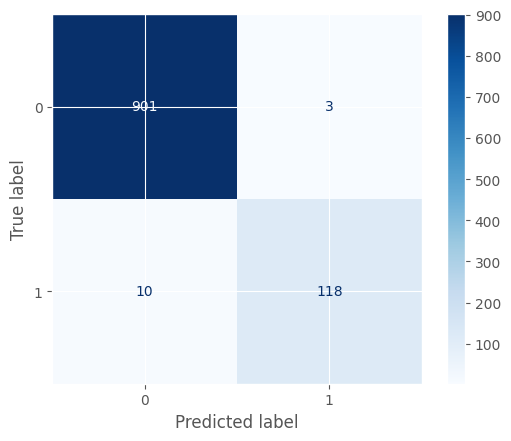

In [373]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test_tfidf,
    y_test,
    cmap = "Blues"
)


In [374]:
emails = [
    "Congratulations! You won a free iPhone. Click here now.",

    "Hey, are we still meeting tomorrow at 10 AM",

    "Go until jurong point, crazy.. Available only",

    "Heey today whether is Good",

    "URGENT! claim super offer only for you limited time period then grab",

    "Congratulations! you go get the order free iphone on amazon only for you .click here immidiately",

    "URGENT! Claim your $1000 Walmart gift card today."
     
]

emails_vectorized = tfidf.transform(emails)

predictions = best_model.predict(emails_vectorized)

for email, prediction in zip(emails, predictions):

    label = "Spam" if prediction == 1 else "Ham"

    print(f"Emial : {email}")

    print(f"Prediction :{label}")

    print("_" * 70)

Emial : Congratulations! You won a free iPhone. Click here now.
Prediction :Spam
______________________________________________________________________
Emial : Hey, are we still meeting tomorrow at 10 AM
Prediction :Ham
______________________________________________________________________
Emial : Go until jurong point, crazy.. Available only
Prediction :Ham
______________________________________________________________________
Emial : Heey today whether is Good
Prediction :Ham
______________________________________________________________________
Emial : URGENT! claim super offer only for you limited time period then grab
Prediction :Spam
______________________________________________________________________
Emial : Congratulations! you go get the order free iphone on amazon only for you .click here immidiately
Prediction :Ham
______________________________________________________________________
Emial : URGENT! Claim your $1000 Walmart gift card today.
Prediction :Spam
______________

In [375]:
import pickle 

with open("spam_classifier.pkl", "wb") as file:

    pickle.dump(best_model, file)

In [376]:
with open ("tfidf_vectorizer.pkl", "wb") as file:
    pickle.dump(tfidf, file)

print("Success")

Success


In [377]:
with open("spam_classifier.pkl","rb")as file:
    loaded_model = pickle.load(file)

with open("tfidf_vectorizer.pkl","rb")as file:

    loaded_vectorizer = pickle.load(file)

In [378]:
email = [
    "Congratulations! You won $1000. Click here"
]

email_vector = loaded_vectorizer.transform(email)

prediction = loaded_model.predict(email_vector)[0]

In [379]:
print("Spam" if prediction ==1 else "Ham")

Spam
